# Architecture Comparison: Baseline vs. Widened vs. Dilated vs. U-Net

Consolidates ticket 2 (`models/architecture_sweep/results.json`),
ticket 3 (`models/dilation_sweep/results.json`), and ticket 4
(`models/unet/results.json`) into one side-by-side comparison. Each
config was re-evaluated (never re-trained) from its own real
checkpoint via the same `evaluate.py` code path, so every number here
is directly comparable, not a mix of old and new computations.

**AUC-PR is the primary metric** (see `CLAUDE.md`'s "Model comparison
summary" -- AUC-ROC is misleadingly high at this project's ~1e-4 to
1e-3 positive rate; AUC-PR is the honest one). AUC-ROC, Cohen's d, F1,
receptive field, and parameter count are reported for context.

## 1. Setup and Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent
MODELS = REPO_ROOT / "models"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"


## 2. Load and Consolidate All Three Sweeps

Every reference checkpoint (the original baseline, ticket 2's winner,
ticket 3's winner) was re-evaluated more than once across these three
files -- deduplicated here by `checkpoint` path (a real, stable
identity: the same file re-evaluated gives bit-identical metrics,
verified before writing this notebook), keeping each real model exactly
once.

In [2]:
raw_rows = []
for path in ["architecture_sweep", "dilation_sweep", "unet"]:
    raw_rows.extend(json.loads((MODELS / path / "results.json").read_text()))

DISPLAY_NAMES = {
    "baseline": "original baseline (32ch, 3L)",
    "baseline (32ch, 3L, no dilation)": "original baseline (32ch, 3L)",
    "h64_l3": "64ch, 3L (ticket 2)",
    "h128_l3": "128ch, 3L (ticket 2)",
    "h32_l5": "32ch, 5L (ticket 2 winner)",
    "ticket2 winner (32ch, 5L, no dilation)": "32ch, 5L (ticket 2 winner)",
    "h128_l5": "128ch, 5L (ticket 2, overfit)",
    "d1-2-4": "dilated [1,2,4] (ticket 3)",
    "d1-2-4-8": "dilated [1,2,4,8] (ticket 3 winner)",
    "reference (dilated d1-2-4-8)": "dilated [1,2,4,8] (ticket 3 winner)",
    "unet_base16": "U-Net, base16 (ticket 4 winner)",
}
FAMILY = {
    "original baseline (32ch, 3L)": "baseline",
    "64ch, 3L (ticket 2)": "ticket 2 (width/depth)",
    "128ch, 3L (ticket 2)": "ticket 2 (width/depth)",
    "32ch, 5L (ticket 2 winner)": "ticket 2 (width/depth)",
    "128ch, 5L (ticket 2, overfit)": "ticket 2 (width/depth)",
    "dilated [1,2,4] (ticket 3)": "ticket 3 (dilation)",
    "dilated [1,2,4,8] (ticket 3 winner)": "ticket 3 (dilation)",
    "U-Net, base16 (ticket 4 winner)": "ticket 4 (U-Net)",
}
# original baseline's params were never freshly measured in any sweep
# script (it was only ever re-evaluated, never retrained) -- known
# value, verified earlier this session via sum(p.numel() for p in model.parameters())
KNOWN_N_PARAMS = {"original baseline (32ch, 3L)": 22593}

seen_checkpoints = set()
rows = []
for r in raw_rows:
    if r["checkpoint"] in seen_checkpoints:
        continue
    seen_checkpoints.add(r["checkpoint"])
    name = DISPLAY_NAMES[r["config"]]
    n_params = r.get("n_params") or KNOWN_N_PARAMS.get(name)
    rows.append({
        "name": name,
        "family": FAMILY[name],
        "n_params": n_params,
        "receptive_field_cells": r.get("receptive_field_cells"),
        "auc_pr": r["auc_pr"],
        "auc_roc": r["auc_roc"],
        "cohens_d": r["cohens_d"],
        "f1_at_best_f1": r["f1_at_best_f1"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "loss_history": r.get("loss_history"),
        "val_loss_history": r.get("val_loss_history"),
    })

df = pd.DataFrame(rows).sort_values("auc_pr", ascending=False).reset_index(drop=True)
print(f"{len(df)} unique real models consolidated")

8 unique real models consolidated


## 3. Full Comparison Table

In [3]:
display_cols = ["name", "family", "n_params", "receptive_field_cells", "auc_pr", "auc_roc", "cohens_d", "f1_at_best_f1"]
df[display_cols].style.format({
    "n_params": "{:,.0f}", "auc_pr": "{:.4f}", "auc_roc": "{:.4f}",
    "cohens_d": "{:.2f}", "f1_at_best_f1": "{:.4f}",
}, na_rep="N/A (no single closed-form RF for a U-Net)")

,name,family,n_params,receptive_field_cells,auc_pr,auc_roc,cohens_d,f1_at_best_f1
0,"U-Net, base16 (ticket 4 winner)",ticket 4 (U-Net),"451,361",N/A (no single closed-form RF for a U-Net),0.0387,0.9882,2.30,0.0960
1,"dilated [1,2,4,8] (ticket 3 winner)",ticket 3 (dilation),"31,841",31.000000,0.0322,0.9861,2.33,0.0883
2,"32ch, 5L (ticket 2 winner)",ticket 2 (width/depth),"41,089",11.000000,0.0319,0.9766,2.45,0.0847
3,"dilated [1,2,4] (ticket 3)",ticket 3 (dilation),"22,593",15.000000,0.0289,0.9823,2.32,0.0825
4,"original baseline (32ch, 3L)",baseline,"22,593",7.000000,0.0283,0.9819,2.49,0.0820
5,"64ch, 3L (ticket 2)",ticket 2 (width/depth),"82,049",7.000000,0.0265,0.9828,2.34,0.0777
6,"128ch, 3L (ticket 2)",ticket 2 (width/depth),"311,553",7.000000,0.0257,0.9831,2.67,0.0717
7,"128ch, 5L (ticket 2, overfit)",ticket 2 (width/depth),"606,721",11.000000,0.0256,0.9653,1.28,0.0783


## 4. AUC-PR: the Primary Comparison

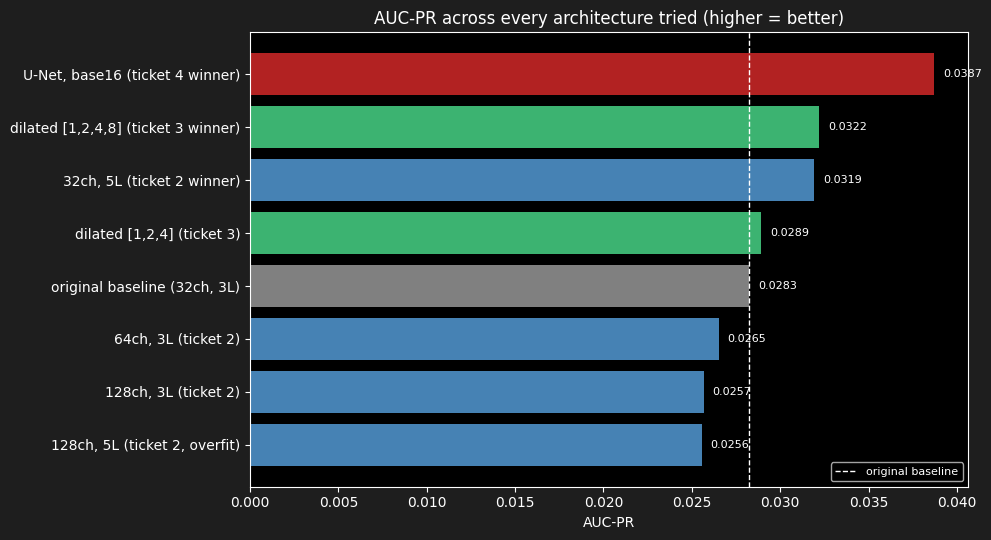

Winner: U-Net, base16 (ticket 4 winner) -- AUC-PR 0.0387 (+37.0% over the original baseline)


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
family_colors = {
    "baseline": "gray",
    "ticket 2 (width/depth)": "steelblue",
    "ticket 3 (dilation)": "mediumseagreen",
    "ticket 4 (U-Net)": "firebrick",
}
colors = [family_colors[f] for f in df["family"]]
bars = ax.barh(df["name"], df["auc_pr"], color=colors)
ax.axvline(df.loc[df["family"] == "baseline", "auc_pr"].iloc[0], color="white", linestyle="--", linewidth=1, label="original baseline")
ax.set_xlabel("AUC-PR")
ax.set_title("AUC-PR across every architecture tried (higher = better)")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=8)
for bar, val in zip(bars, df["auc_pr"]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

winner = df.iloc[0]
baseline_pr = df.loc[df["family"] == "baseline", "auc_pr"].iloc[0]
print(f"Winner: {winner['name']} -- AUC-PR {winner['auc_pr']:.4f} "
      f"(+{(winner['auc_pr'] / baseline_pr - 1) * 100:.1f}% over the original baseline)")

## 5. AUC-ROC vs. AUC-PR -- the Same Trap, Every Time

Confirms, across all 8 models rather than just one, the finding from
`notebooks/model_comparison_summary.ipynb`: AUC-ROC stays in a narrow,
uniformly high band regardless of real quality differences, while
AUC-PR actually separates the models.

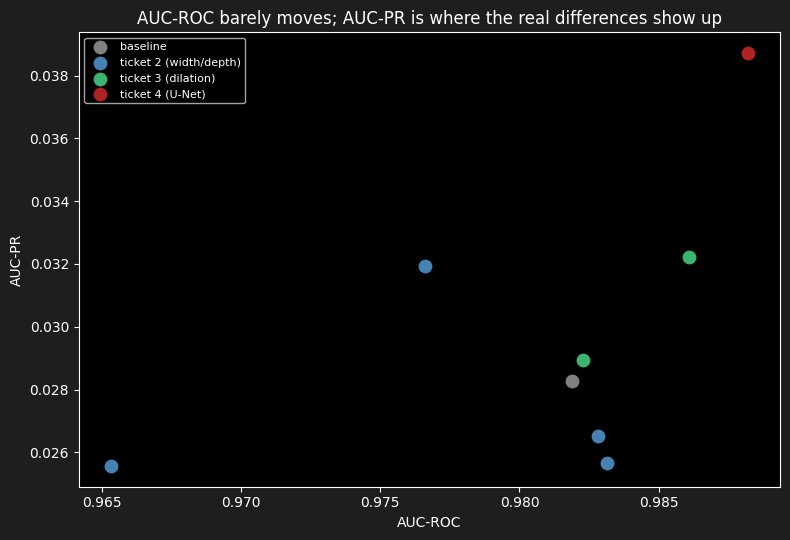

AUC-ROC range: 0.9653 - 0.9882 (span: 0.0229)
AUC-PR range:  0.0256 - 0.0387 (span: 0.0132)


In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for family, color in family_colors.items():
    subset = df[df["family"] == family]
    ax.scatter(subset["auc_roc"], subset["auc_pr"], color=color, label=family, s=80)
ax.set_xlabel("AUC-ROC")
ax.set_ylabel("AUC-PR")
ax.set_title("AUC-ROC barely moves; AUC-PR is where the real differences show up")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"AUC-ROC range: {df['auc_roc'].min():.4f} - {df['auc_roc'].max():.4f} (span: {df['auc_roc'].max()-df['auc_roc'].min():.4f})")
print(f"AUC-PR range:  {df['auc_pr'].min():.4f} - {df['auc_pr'].max():.4f} (span: {df['auc_pr'].max()-df['auc_pr'].min():.4f})")

## 6. Parameter Count vs. AUC-PR: Does Bigger Actually Mean Better?

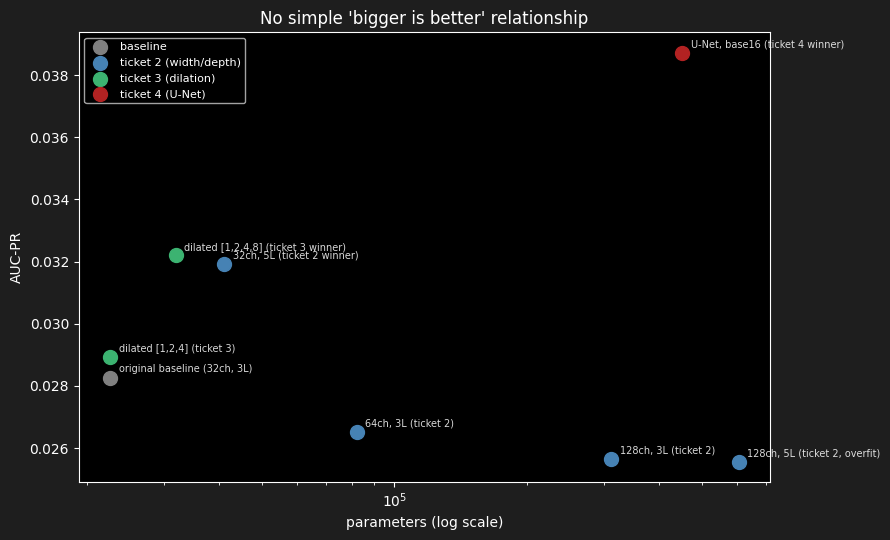

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for family, color in family_colors.items():
    subset = df[df["family"] == family]
    ax.scatter(subset["n_params"], subset["auc_pr"], color=color, label=family, s=100)
    for _, row in subset.iterrows():
        ax.annotate(row["name"], (row["n_params"], row["auc_pr"]), fontsize=7,
                    xytext=(6, 4), textcoords="offset points", alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("parameters (log scale)")
ax.set_ylabel("AUC-PR")
ax.set_title("No simple 'bigger is better' relationship")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

Not a clean trend: `128ch/3L` and `128ch/5L` (ticket 2's widest,
most over-parameterized configs) sit *below* several far smaller
models. The U-Net is both the largest model shown and the best --
but the very next best (dilated `[1,2,4,8]`) is one of the smallest.
Parameter count alone doesn't predict AUC-PR here; what mattered was
*how* the extra capacity was used (more receptive field vs. just more
channels).

## 7. Loss Curves: Checking for Overfitting

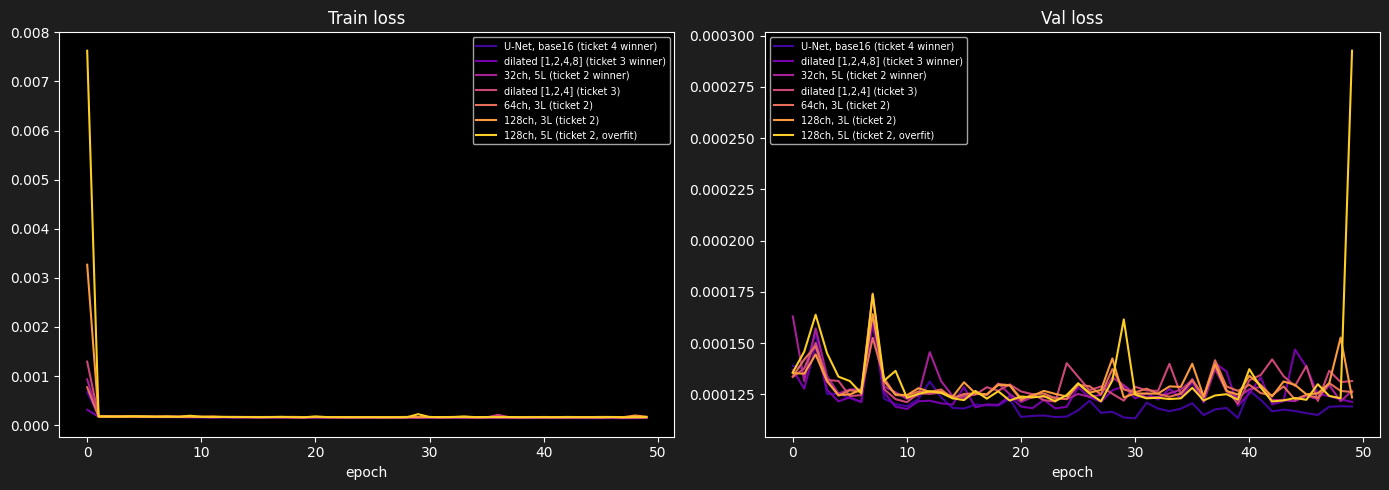

                               name  final_train_loss  final_val_loss  val_over_train_ratio
    U-Net, base16 (ticket 4 winner)          0.000146        0.000119              0.815916
dilated [1,2,4,8] (ticket 3 winner)          0.000157        0.000121              0.774046
         32ch, 5L (ticket 2 winner)          0.000156        0.000127              0.811349
         dilated [1,2,4] (ticket 3)          0.000158        0.000132              0.833475
                64ch, 3L (ticket 2)          0.000162        0.000126              0.778781
               128ch, 3L (ticket 2)          0.000172        0.000124              0.718574
      128ch, 5L (ticket 2, overfit)          0.000163        0.000293              1.796987


In [7]:
trained = df[df["loss_history"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.plasma(np.linspace(0.1, 0.9, len(trained)))
for color, row in zip(cmap, trained.itertuples()):
    axes[0].plot(row.loss_history, color=color, label=row.name, linewidth=1.5)
    axes[1].plot(row.val_loss_history, color=color, label=row.name, linewidth=1.5)
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].legend(fontsize=7)
axes[1].set_title("Val loss")
axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(trained[["name", "final_train_loss", "final_val_loss"]].assign(
    val_over_train_ratio=lambda d: d["final_val_loss"] / d["final_train_loss"]
).to_string(index=False))

**`128ch/5L` (ticket 2's combined-axes config) is the clear
overfitting outlier** -- val loss ~2x train loss, visibly diverging in
the right panel while every other config's train/val curves track
closely together. The U-Net, despite having by far the most
parameters of any config here, shows no such divergence -- val loss is
essentially equal to (fractionally below) train loss, the same healthy
pattern as the small dilated/depth-widened configs. Parameter count
alone didn't cause the overfitting seen in ticket 2; a flat
architecture with no relief valve for that capacity did.

## 8. Verdict

**Winner: the U-Net (`base_channels=16`), AUC-PR 0.0387.** Beats every
other architecture tried, including the next-best (ticket 3's dilated
`[1,2,4,8]`, 0.0322) by +20.2%, and the original baseline (0.0283) by
+36.7%. Also best on AUC-ROC (0.9882) and best-F1 (0.0960), and shows
no overfitting despite ~14x the parameters of the next-largest
competitive model.

**Why, in one sentence**: every architecture that grew *receptive
field* (more plain layers, dilation, or the U-Net's downsample/upsample
structure) beat the ones that only grew *raw capacity* (channel
width alone) -- and the U-Net's multi-scale structure is the most
effective way tried so far to grow receptive field without also
growing overfitting risk.

**Honest caveats, not glossed over**:
- All 8 models share one fixed hyperparameter recipe (`alpha=0.25,
  lr=1e-3`, 50 epochs) tuned around the *original* small baseline --
  no architecture here got its own hyperparameter tuning pass. The
  U-Net's win could understate its real potential, or the recipe could
  happen to suit it unusually well; this comparison can't distinguish
  those.
- The U-Net was trained as **one config**, not swept (unlike tickets
  2-3's ablations) -- `base_channels` and downsample depth are both
  open, untested dimensions. A wider or deeper U-Net might do better,
  or might start overfitting the way ticket 2's channel-widening did;
  this notebook doesn't know which.
- Absolute AUC-PR is still low in absolute terms (0.0387, vs. a
  no-skill baseline around the ~1.5-2e-4 positive rate) -- a real,
  substantial signal (~190-260x the no-skill baseline) but this is
  still a hard, heavily-imbalanced problem, not a solved one.

**If a bigger model had *not* beaten the baseline, that would have
been reported exactly as honestly** -- it wasn't necessary to spin
this result; three of four widening directions tried (ticket 2's
channels-only widening, both of them) did *not* beat the baseline, and
`CLAUDE.md` already documents that plainly.